In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pandas as pd
import re
import rasterio
from rasterio.transform import from_origin
from pyproj import Transformer
import re
import scipy as sp
import pyreadr
import sys
sys.path.append(os.path.abspath('../src/'))
from utils import *
from scipy import stats
import argparse
import copy
import glob
import argparse
import cProfile
import csv
from functools import partial
import itertools
import math
import matplotlib.pyplot as plt
import multiprocessing as mp
import numpy as np
import os
import rasterio
from scipy import stats
from scipy.optimize import minimize
# from scipy.special import binom
from skimage import graph
import sys
import time
from tqdm import tqdm
import numpy.ma as ma
import warnings
import numpy as np
import psutil
import gc

warnings.filterwarnings("ignore")

import logging
logging.getLogger("distributed").setLevel(logging.ERROR)


Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


In [3]:
def compute_expected_n(ac_locs, trap_locs, g0, sigma, K, density, prob_cap, trap_x):
    """
    Computes expected number of unique individuals detected in a spatial capture-recapture study.
        ac_locs (2D array): Shape (num_activity_centers, 2) - x and y coordinates of activity centers.
        trap_locs (2D array): Shape (num_traps, 2) - x and y coordinates of all potential trap locations.
        g0 (float): Detection probability at the activity center.
        sigma (float): Scale parameter of the detection function.
        K (int): Number of sampling periods.
        density (float): Density of individuals per unit area.
        prob_cap (2D array): Shape (num_traps, num_activity_centers) - capture probability at each trap j of individuals with activity center l.
        trap_x (1D array): 1D array of activated trap locations.
    """
    for t in range(len(trap_locs)): # for trap locations that are not selected, set all capture probs to 0
        if int(trap_x[t]) == 0:
            prob_cap[t,...] = np.zeros(ac_locs.shape[0])

    i_cap_hist = np.squeeze(np.zeros((len(trap_locs), 1)))  # Initialize empty capture history 
    p_empty_cap_hist = compute_cond_lik_ind(len(ac_locs), prob_cap, K, len(trap_locs), i_cap_hist)
    p_nonempty = 1 - p_empty_cap_hist
    expected_n = np.sum(p_nonempty*density)
    return expected_n

def compute_cond_lik_ind(num_activity_centers, est_prob_cap, K, num_traps, ind_cap_hist):
    """
    Computes the likelihood of an individual's capture history conditional on their activity center location. 
        est_prob_cap (2D array): Shape (num_traps, num_activity_centers) - capture probability at each trap j of individuals with activity center l.   
        num_activity_centers (int): Number of potential activity centers. 
        K (int): Number of sampling periods.
        num_traps (int): Number of potential trap locations.
        ind_cap_hist (1D array): Capture history of an individual.
    """
    broadcast_i_cap_hist = np.broadcast_to(ind_cap_hist[:, np.newaxis], (num_traps, num_activity_centers))      # Reshapes to array of shaep (num_traps, num_activity_centers)
    probs = stats.binom.pmf(broadcast_i_cap_hist, K, est_prob_cap)
    zero_mask = probs == 0.0
    log_probs = np.log(probs, where=np.invert(zero_mask))
    log_probs[zero_mask] = -sys.maxsize - 1
    log_cond_lik_sums = np.sum(log_probs, axis=0)
    return np.exp(log_cond_lik_sums)

def compute_expected_n_across_scenarios(ac_locs, trap_locs, g0, sigma, K, density, prob_cap, trap_x):
    nscenarios = len(g0)
    e_n = np.zeros((nscenarios,1))
    for s in range(nscenarios):
        e_n[s,0] = compute_expected_n(ac_locs, trap_locs, g0[s], sigma[s], K, density[s], prob_cap[s], trap_x)
    return(e_n)

In [4]:
def compute_expected_c(ac_locs, trap_locs, g0, sigma, K, density, prob_cap, trap_x):
    """
    Computes expected number of captures.
        ac_locs (2D array): Shape (num_activity_centers, 2) - x and y coordinates of activity centers.
        trap_locs (2D array): Shape (num_traps, 2) - x and y coordinates of all potential trap locations.
        g0 (float): Detection probability at the activity center.
        sigma (float): Scale parameter of the detection function.
        K (int): Number of sampling periods.
        density (float): Density of individuals per unit area.
        prob_cap (2D array): Shape (num_traps, num_activity_centers) - capture probability at each trap j of individuals with activity center l.
        trap_x (1D array): 1D array of activated trap locations.
    """
    density_array = np.array(density).flatten()
    
    # For trap locations that are not selected, set all capture probs to 0
    for t in range(len(trap_locs)):
        if int(trap_x[t]) == 0:
            prob_cap[t,...] = np.zeros(ac_locs.shape[0])
    
    # Compute the expected number of captures
    broadcast_density = np.broadcast_to(density_array, (len(trap_locs), len(density_array)))    # Repeats density to shape of (num_traps, num_activity_centers)
    expected_c = np.sum(prob_cap*broadcast_density)*K
    return expected_c

def compute_expected_c_across_scenarios(ac_locs, trap_locs, g0, sigma, K, density, prob_cap, trap_x):
    nscenarios = len(g0)
    e_c = np.zeros((nscenarios,1))
    for s in range(nscenarios):
        e_c[s,0] = compute_expected_c(ac_locs, trap_locs, g0[s], sigma[s], K, density[s], prob_cap [s], trap_x)
    return(e_c)

In [5]:
def backward_greedy(scenarios, trap_loc, centers, K, distances):
    # Initailize all potential trap locations to have a camera.
    trap_x = np.ones((len(trap_loc),))

    # Initailize parameter storage across scenarios
    D = []
    g0 = []
    sigma = []
    density_prior = []
    alpha1 = []
    prob_cap = []

    # Intiailize storage of loss functions
    # E_n_curr = []
    # E_c_curr = []
    # E_r_curr = []
    # RSE_curr = []
    # RSE_hist = []

    # Initialize txt files to store E_n, E_c, E_r, and RSE
    with open('data/e_n.txt', 'w') as f:
        f.write('E_n\n')
    with open('data/e_c.txt', 'w') as f:
        f.write('E_c\n')
    with open('data/e_r.txt', 'w') as f:
        f.write('E_r\n')
    with open('data/rse.txt', 'w') as f:
        f.write('RSE\n')
    with open('data/rse_hist.txt', 'w') as f:
        f.write('RSE_hist\n')


    # For each scenario, calculate the RSE in the event all potential trap locations are activated.
    for s in range(len(scenarios)):
        print(s)
        D.append(scenarios[s][0])
        g0.append(scenarios[s][1])
        sigma.append(scenarios[s][2])
        density_prior.append(np.ones((centers.shape[0]))*(47/float(centers.shape[0])))      # List of Length # of potential activity centers
        # Read in density prior file from /data/density if not using uniform density
        # density_prior_file =  f'data/density/Dmod_draw_{s+1}.csv'
        # density_df = pd.read_csv(density_prior_file)
        # density_grid = density_df.pivot_table(values='D_mod',index='x',columns='y', fill_value = 0).astype(np.float64).values.T 
        # density_prior.append(density_grid)
        alpha1.append(1/(2*sigma[s]*sigma[s]))
        prob_cap.append((g0[s])*np.exp(-alpha1[s]*(distances**2)))      # Array of size (# traps, # poential activity centers)

        # Compute RSE for the current scenario when all trap locations are activated
        # E_n_cur.append(compute_expected_n(centers, trap_loc, g0[s], sigma[s], K, density_prior[s], prob_cap[s], trap_x))
        # E_n_curr = compute_expected_n(centers, trap_loc, g0[s], sigma[s], K, density_prior[s], prob_cap[s], trap_x)
        # with open('data/e_n.txt', 'a') as f:
        #     f.write(f'{E_n_curr}\n')
        
        # E_c_curr.append(compute_expected_c(centers, trap_loc, g0[s], sigma[s], K, density_prior[s], prob_cap[s], trap_x))
        # E_c_curr = compute_expected_c(centers, trap_loc, g0[s], sigma[s], K, density_prior[s], prob_cap[s], trap_x)
        # with open('data/e_c.txt', 'a') as f:
        #     f.write(f'{E_c_curr}\n')
        # # E_r_curr.append(E_c_curr[s] - E_n_curr[s])
        # E_r_curr = E_c_curr - E_n_curr
        # with open('data/e_r.txt', 'a') as f:
        #     f.write(f'{E_r_curr}\n')
        # # RSE_curr.append(1/np.sqrt(min([E_n_curr[s], E_r_curr[s]])))
        # RSE_curr = 1/np.sqrt(min([E_n_curr, E_r_curr]))
        # with open('data/rse.txt', 'a') as f:
        #     f.write(f'{RSE_curr}\n')

    # # Average performance across all scenarios when all trap locations are activated
    # print("Computing Avg RSE Across Scenarios")
    # # RSE_hist.append(np.mean(RSE_curr))
    # RSE_hist = np.mean(RSE_curr)
    # with open('data/rse_hist.txt', 'a') as f:
    #     f.write(f'{RSE_hist}\n')
    # remove_hist = []

    # # Begin backward greedy approach - removing 1 camera at a time
    # counter = 0
    # while sum(trap_x) > 60:    # Set mininum number of cameras -- dependent on scenario
    #     counter += 1           # Tracks number of camera removals
    #     print(counter)
    #     trap_indices = [i for i, x in enumerate(trap_x) if int(x) == 1]       # Locations where traps which are still activated
    #     trap_x_temp = np.copy(np.broadcast_to(trap_x, (len(trap_indices),trap_x.shape[0])))    # 2D array of shape (num_activated_trap_locs, num_possible_trap_locs)

    #     # Temporarily remove each currently active location to 0 and simulate the performance
    #     for pos in range(len(trap_indices)):
    #         trap_idx = trap_indices[pos]
    #         trap_x_temp[pos, trap_idx] = 0 

    #     # Multiprocess the E_n and E_c calculations
    #     func1 = partial(compute_expected_n_across_scenarios, centers, trap_loc, g0, sigma, K, density_prior, prob_cap)   # Setup all parameters but the activated trap locations
    #     func2 = partial(compute_expected_c_across_scenarios, centers, trap_loc, g0, sigma, K, density_prior, prob_cap)
    #     pool = mp.Pool(min(mp.cpu_count(), 10))
    #     E_n_per_scenario = np.squeeze(np.array(pool.map(func1, trap_x_temp)))
    #     E_c_per_scenario = np.squeeze(np.array(pool.map(func2, trap_x_temp)))
    #     pool.close()
    #     pool.join()

    #     # Calculate RSE
    #     E_r_per_scenario = E_c_per_scenario
    #     min_n_r_per_scenario = np.zeros(E_r_per_scenario.shape)
    #     RSE_per_scenario = np.zeros(E_r_per_scenario.shape)
    #     for t in range(len(trap_indices)):
    #         for s in range(len(scenarios)):
    #             E_r_per_scenario[t,s] -= E_n_per_scenario[t,s]
    #             min_n_r_per_scenario[t,s] = min(E_n_per_scenario[t,s], E_r_per_scenario[t,s])
    #             RSE_per_scenario[t,s] = 1/np.sqrt(min_n_r_per_scenario[t,s])
    #     RSE_temp = np.mean(RSE_per_scenario, axis=1).tolist()

    #     # Select which trap to remove based on RSE
    #     min_change_idx = RSE_temp.index(min(RSE_temp)) 
    #     remove = trap_indices[min_change_idx]
    #     trap_x[remove] = 0

    #     # Track removal history
    #     RSE_hist.append(RSE_temp[min_change_idx])
    #     remove_hist.append(remove)
    #     print(remove, RSE_temp[min_change_idx])
    
    # return(remove_hist, RSE_hist)


In [45]:
# Read in parameter draws
params = pd.read_csv('./500m_data/param_values_for_each_draw300.csv')
params = params.rename(columns={'Unnamed: 0': 'index'})

# Extract parameter values
D = params['D'].values
g0 = params['g0'].values
sigma = params['sigma'].values
K= 5    # Number of sampling periods
# raster_cell_size = np.full(params.shape[0], 100) -- Not needed since using UTM coordinates

# Read in potential activity center locations
ac_coords = pyreadr.read_r('./500m_data/500m_mask.RDS')
ac_coords = ac_coords[None]
ac_coords_list = ac_coords[['x', 'y']].values.tolist()
ac_coords_list = np.array(ac_coords_list)

# Read in potential trap locations
trap_coords = pd.read_csv('./500m_data/500m_trap_grid.csv')
trap_coords = trap_coords.drop(columns = ['Unnamed: 0'])
trap_coords = trap_coords.rename(columns = {'X': 'x', 'Y': 'y'})
trap_coords_list = []
for i in range(trap_coords.shape[0]):
    trap_coords_list.append((trap_coords['x'][i], trap_coords['y'][i]))
trap_coords_list = np.array(trap_coords_list)

# Randomly select 1000 trap locations and activity centers -- Comment out when not testing
# np.random.seed(42)
# np.random.shuffle(ac_coords_list)
# ac_coords_list = (ac_coords_list)[:100]
# np.random.shuffle(trap_coords_list)
# trap_coords_list = (trap_coords_list)[:100]

# Calculate euclidean distances from traps to activity centers
traps = trap_coords_list[:, np.newaxis, :]
centers = ac_coords_list[np.newaxis, :, :] 
differences = traps - centers
distances = np.linalg.norm(differences, axis=2)

scenarios = list(zip(*[D, g0, sigma]))

# backward_greedy(scenarios, trap_coords_list, ac_coords_list, K, distances)

In [33]:
ac_coords_list

array([[ 508737.78721529, 5623510.46939679],
       [ 509237.78721529, 5623510.46939679],
       [ 509737.78721529, 5623510.46939679],
       ...,
       [ 491737.78721529, 5674010.46939679],
       [ 492237.78721529, 5674010.46939679],
       [ 492737.78721529, 5674010.46939679]])

In [36]:
traps = pd.read_csv('500m_data/500m_trap_grid.csv')

# for each row, which is a list of integers, in activated_trap_hist.txt, generated a file to put in testing_viz which represenst the lat/long values of that trap, as found in 500m_trap_grid.csv
with open('500m_data/activated_trap_hist.txt', 'r') as f:
    lines = f.readlines()
    i = 0
    for line in lines:
        locs = pd.DataFrame(columns = ['x', 'y'])
        # convert to list of integers
        line = line.strip()
        line = re.sub(r'\[|\]|\'', '', line)
        line = line.split(',')
        line = [int(i) for i in line]
        for item in line:
            # find the id that equals item + 1
            item_id = item + 1
            loc = traps.loc[traps['Trap_index'] == item_id]
            # get the values from the x and y columns in traps and add to locs
            loc = loc[['x', 'y']]
            locs = pd.concat([locs, loc], ignore_index=True)

        # save locs to a csv file in the testing_viz folder
        locs.to_csv(f'500m_data/testing_viz/activated_trap_{i}.csv', index=False)

        i += 1


In [27]:
np.ones((centers.shape[0]))*(47/float(centers.shape[0]))


array([47.])

In [29]:
centers[0].shape[0] # Number of potential activity centers

8485

In [31]:
traps.shape

(2437, 1, 2)

In [ ]:

def compute_expected_n(ac_locs, trap_locs, g0, sigma, K, density, distances, trap_x):
    """
    Computes expected number of unique individuals detected in a spatial capture-recapture study.
        ac_locs (2D array): Shape (num_activity_centers, 2) - x and y coordinates of activity centers.
        trap_locs (2D array): Shape (num_traps, 2) - x and y coordinates of all potential trap locations.
        g0 (float): Detection probability at the activity center.
        sigma (float): Scale parameter of the detection function.
        K (int): Number of sampling periods.
        density (float): Density of individuals per unit area.
        prob_cap (2D array): Shape (num_traps, num_activity_centers) - capture probability at each trap j of individuals with activity center l.
        trap_x (1D array): 1D array of activated trap locations.
    """
    alpha1 = (1/(2*sigma*sigma))
    prob_cap = ((g0)*np.exp(-alpha1*(distances**2)))      # Array of size (# traps, # poential activity centers)

    for t in range(len(trap_locs)): # for trap locations that are not selected, set all capture probs to 0
        if int(trap_x[t]) == 0:
            prob_cap[t,...] = np.zeros(ac_locs.shape[0])
    i_cap_hist = np.squeeze(np.zeros((len(trap_locs), 1)))  # Initialize empty capture history 
    p_empty_cap_hist = compute_cond_lik_ind(len(ac_locs), prob_cap, K, len(trap_locs), i_cap_hist)
    p_nonempty = 1 - p_empty_cap_hist
    expected_n = np.sum(p_nonempty*density)
    return expected_n

In [56]:
ac_coords_list

array([[ 508737.78721529, 5623510.46939679],
       [ 509237.78721529, 5623510.46939679],
       [ 509737.78721529, 5623510.46939679],
       ...,
       [ 491737.78721529, 5674010.46939679],
       [ 492237.78721529, 5674010.46939679],
       [ 492737.78721529, 5674010.46939679]])

In [54]:
density_prior_file =  '500m_data/density/Dmod_draw_1.csv'
density_df = pd.read_csv(density_prior_file)
density_df

# for each activity center in ac_coords_list, get the cell_dnensity value from the density_df file
cell_densities = []
for coord in ac_coords_list:  # assuming centers[0] is a list of (x, y) tuples
    x,y = coord
    print(x,y)
    x = round(x,9)
    y = round(y,8) 
    print(x,y)
    print('---')
    # row = density_df.loc[(round(density_df['x'],9) == x) & (round(density_df['y'],8) == y)]
    # cell_density = row['cell_density'].values[0]  # get the scalar value
    # print(f"Coordinates ({x}, {y}) have cell_density: {cell_density}")


# # Create a list 'density' which has the cell_density value in density_prior_file, ordered by the same x and y coordinate as in ac_coords_list
# density = []
# for i in range(ac_coords_list.shape[0]):
#     x = ac_coords_list[i][0]
#     y = ac_coords_list[i][1]
#     # find the row in density_df where x and y are equal to the x and y in ac_coords_list
#     row = density_df.loc[(density_df['x'] == x) & (density_df['y'] == y)]
#     # get the value of cell_density from that row
#     cell_density = row['cell_density']
#     density.append(cell_density)
# density = np.array(density)
# density

# density_grid = density_df.pivot_table(vlues='D_mod',index='x',columns='y', fill_value = 0).astype(np.float64).values.T 
# density_grid

508737.7872152887 5623510.469396791
508737.787215289 5623510.46939679
---
509237.7872152887 5623510.469396791
509237.787215289 5623510.46939679
---
509737.7872152887 5623510.469396791
509737.787215289 5623510.46939679
---
510237.7872152887 5623510.469396791
510237.787215289 5623510.46939679
---
510737.7872152887 5623510.469396791
510737.787215289 5623510.46939679
---
511237.7872152887 5623510.469396791
511237.787215289 5623510.46939679
---
511737.7872152887 5623510.469396791
511737.787215289 5623510.46939679
---
512237.7872152887 5623510.469396791
512237.787215289 5623510.46939679
---
512737.7872152887 5623510.469396791
512737.787215289 5623510.46939679
---
513237.7872152887 5623510.469396791
513237.787215289 5623510.46939679
---
506237.7872152887 5624010.469396791
506237.787215289 5624010.46939679
---
506737.7872152887 5624010.469396791
506737.787215289 5624010.46939679
---
507237.7872152887 5624010.469396791
507237.787215289 5624010.46939679
---
507737.7872152887 5624010.469396791
50

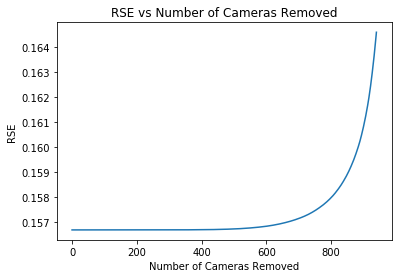

In [12]:
# read in rse_hist.txt
with open('500m_data/rse_hist.txt', 'r') as f:
    lines = f.readlines()
    # convert to list of floats
    lines = [float(i.strip()) for i in lines]
    # convert to numpy array
    rse_hist = np.array(lines)

rse_hist

# plot these values in a line graph
plt.plot(rse_hist)
plt.xlabel('Number of Cameras Removed')
plt.ylabel('RSE')
plt.title('RSE vs Number of Cameras Removed')
plt.show()